<Axes: xlabel='$s$', ylabel='$P$'>

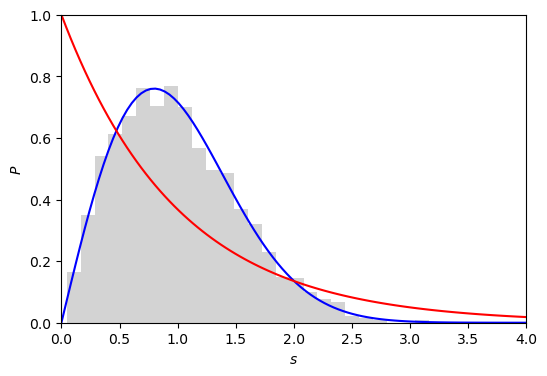

In [3]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

op = qt.generate.operas.spin

L = 14

builder = op.builder()
for i in range(L-1):
    builder += 'xx', [i, i+1], 1.
    builder += 'yy', [i, i+1], 1.
    builder += 'zz', [i, i+1], 1.
    builder += 'z', [i,], np.random.rand()
ham = builder.build()

basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)
mat = ham.to_matrix(basis=basis)
eng = np.linalg.eigvalsh(mat)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

xs = np.linspace(0,4,100)
ys = qt.quantity.WignerDyson_distribution(xs)
ax.plot(xs, ys, label='Wigner-Dyson', color='blue')

ys = qt.quantity.Poisson_distribution(xs)
ax.plot(xs, ys, label='Poisson', color='red')

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$P$")

ax.set_xlim(0, 4)
ax.set_ylim(0, 1)

eng_unfold = qt.quantity.unfolding_diff(eng)
qt.quantity.plot_level_spacing_distribution(eng_unfold, ax)

In [9]:
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import numpy as np
xs = np.random.randn(100)
ys = np.random.randn(100)
data = np.column_stack((xs, ys))
tree = cKDTree(data)
dists, _ = tree.query(data, k=31)  # k=31 to include the point itself as the 0th
dists[:, 2]

array([1.43093246, 0.22754821, 0.2426754 , 0.16005864, 0.25909794,
       0.24175134, 0.26599029, 0.57365358, 0.20894131, 0.13020597,
       0.14166273, 0.12269087, 0.24687834, 0.49380526, 0.26496763,
       0.15481077, 0.17949271, 0.2656968 , 0.25356907, 0.2330014 ,
       0.24589282, 0.32064617, 0.2656968 , 0.212849  , 0.31285566,
       0.17546876, 0.56925842, 0.34538923, 0.18170786, 0.19938726,
       0.212849  , 1.18382032, 0.28266418, 0.14671768, 0.12985774,
       0.60171551, 0.26703054, 0.26789406, 0.44430881, 0.07912264,
       0.30889204, 0.51629648, 0.24516016, 0.19938726, 0.3295185 ,
       0.29064407, 0.31285566, 0.15891201, 0.19536086, 0.28086728,
       0.17949271, 0.34944138, 1.04518511, 0.45490169, 0.31604542,
       0.14091966, 0.66341609, 0.66573313, 0.25122791, 0.14337721,
       0.83412679, 0.32896813, 0.47993142, 0.65318002, 0.25508556,
       0.26858837, 0.31147683, 0.1793238 , 0.4221224 , 0.44961283,
       0.26851888, 0.39188927, 0.13479015, 0.39665639, 0.57365